<a href="https://colab.research.google.com/github/mw2304/SummerProject2026/blob/main/ThreeG_SCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install uproot
%pip install awkward_pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.8/405.8 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.1/990.1 kB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.7/698.7 kB 53.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import uproot
import os

import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

RANDOM_STATE = 42


In [3]:
ROOT_FILE = "threegamma.root"

file = uproot.open(ROOT_FILE)
print(file.keys())

tree = file["ThreeG_PhantomSCS"]
print(tree.keys())

branches = [
    "RunID", "EventID",
    "GammaIndex", "NGammas",
    "X_mm", "Y_mm", "Z_mm",
    "EnergyDeposit_keV", "PreEnergy_keV", "PostEnergy_keV",
    "AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm",
    "HitIndex", "VolumeID", "ProcessID" ]

df = tree.arrays(branches, library="pd")
df.head()

['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_PhantomSCS;1', 'ThreeG_PhantomDCS;1', 'ThreeG_PhantomTCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['RunID', 'EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


,RunID,EventID,GammaIndex,NGammas,X_mm,Y_mm,Z_mm,EnergyDeposit_keV,PreEnergy_keV,PostEnergy_keV,AnnihilX_mm,AnnihilY_mm,AnnihilZ_mm,HitIndex,VolumeID,ProcessID
0,slurm_36690178_1,17,0,3,-4.520162,3.594327,-10.462225,67.052460,365.556824,298.504364,-0.876325,4.981189,-7.555530,0,0,0
1,slurm_36690178_1,17,0,3,-55.741810,-15.481056,-0.845658,298.504364,298.504364,0.000000,-0.876325,4.981189,-7.555530,1,1,1
2,slurm_36690178_1,17,1,3,42.979733,-1.089722,-31.962778,276.883209,276.883209,0.000000,-0.876325,4.981189,-7.555530,0,1,1
3,slurm_36690178_1,17,2,3,4.262092,25.936068,46.114967,379.557770,379.557770,0.000000,-0.876325,4.981189,-7.555530,0,1,1
4,slurm_36690178_1,22,0,3,41.713409,-42.592724,-13.575642,443.821381,443.821381,0.000000,3.334872,2.525445,-7.544209,0,1,1


In [4]:
# Only use scanner photoelectric hits
df_SCS = df[
    (df["VolumeID"] == 1) &
    (df["ProcessID"] == 1)
].copy()

print("Total scanner photoelectric hits:", len(df_SCS))
print("Number of events:", df_SCS[["RunID", "EventID"]].drop_duplicates().shape[0])

print("\nHits per event:")
print(
    df_SCS.groupby(["RunID", "EventID"]).size().value_counts().sort_index()
)

Total scanner photoelectric hits: 35919
Number of events: 11973

Hits per event:
3    11973
Name: count, dtype: int64


In [13]:
def build_event_arrays_plane_SCS(df_events):

    features_list = []
    targets_list = []
    plane_list = []

    for (run_id, event_id), event in df_events.groupby(
        ["RunID", "EventID"]
    ):

        # Sort scanner hits by decreasing energy
        event = event.sort_values(
            ["EnergyDeposit_keV", "GammaIndex"],
            ascending=[False, True]
        ).reset_index(drop=True)

        # Need exactly three scanner photoelectric hits
        if len(event) != 3:
            continue

        event = event.iloc[:3]

        # Hit coordinates
        hit1 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[0].values.astype(float)

        hit2 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[1].values.astype(float)

        hit3 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[2].values.astype(float)

        # Construct the plane
        v1 = hit2 - hit1
        v2 = hit3 - hit1

        normal = np.cross(v1, v2)
        normal_length = np.linalg.norm(normal)

        if normal_length < 1e-8:
            continue

        normal = normal / normal_length

        basis_u = v1 / (
            np.linalg.norm(v1) + 1e-8
        )

        basis_v = np.cross(normal, basis_u)

        basis_v = basis_v / (
            np.linalg.norm(basis_v) + 1e-8
        )

        # Store information needed to convert UV back to XYZ
        plane_data = np.concatenate([
            hit1,
            normal,
            basis_u,
            basis_v
        ])

        plane_list.append(plane_data)

        # Energies
        energy1 = float(
            event.iloc[0]["EnergyDeposit_keV"]
        )

        energy2 = float(
            event.iloc[1]["EnergyDeposit_keV"]
        )

        energy3 = float(
            event.iloc[2]["EnergyDeposit_keV"]
        )

        # Distances between scanner hits
        d12 = np.linalg.norm(hit1 - hit2)
        d13 = np.linalg.norm(hit1 - hit3)
        d23 = np.linalg.norm(hit2 - hit3)

        # Gamma opening angle
        def gamma_opening_angle(e_i, e_j, e_k):

            cos_theta = (
                -e_i**2
                -e_j**2
                +e_k**2
            ) / (2 * e_i * e_j + 1e-8)

            return np.arccos(
                np.clip(cos_theta, -1.0, 1.0)
            )

        angle1 = gamma_opening_angle(
            energy1, energy2, energy3
        )

        angle2 = gamma_opening_angle(
            energy2, energy3, energy1
        )

        angle3 = gamma_opening_angle(
            energy3, energy1, energy2
        )

        # Model inputs
        features = np.concatenate([
            hit1, [energy1],
            hit2, [energy2],
            hit3, [energy3],
            [d12, d13, d23],
            [angle1, angle2, angle3]
        ])

        features_list.append(features)

        # Annihilation position = target
        target = event[
            [
                "AnnihilX_mm",
                "AnnihilY_mm",
                "AnnihilZ_mm"
            ]
        ].iloc[0].values.astype(float)

        targets_list.append(target)

    return (
        np.array(features_list),
        np.array(targets_list),
        np.array(plane_list)
    )

In [14]:
X_plane_SCS, y_plane_SCS, plane_data_plane_SCS = \
    build_event_arrays_plane_SCS(df_SCS)

print("X_plane_SCS shape:", X_plane_SCS.shape)
print("y_plane_SCS shape:", y_plane_SCS.shape)
print("plane_data_plane_SCS shape:", plane_data_plane_SCS.shape)

X_plane_SCS shape: (11973, 18)
y_plane_SCS shape: (11973, 3)
plane_data_plane_SCS shape: (11973, 12)


In [15]:
X_train_plane_SCS, X_temp_plane_SCS, \
y_train_plane_SCS, y_temp_plane_SCS, \
plane_train_plane_SCS, plane_temp_plane_SCS = train_test_split(
    X_plane_SCS,
    y_plane_SCS,
    plane_data_plane_SCS,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_val_plane_SCS, X_test_plane_SCS, \
y_val_plane_SCS, y_test_plane_SCS, \
plane_val_plane_SCS, plane_test_plane_SCS = train_test_split(
    X_temp_plane_SCS,
    y_temp_plane_SCS,
    plane_temp_plane_SCS,
    test_size=0.33,
    random_state=RANDOM_STATE
)

print("Training:", X_train_plane_SCS.shape)
print("Validation:", X_val_plane_SCS.shape)
print("Test:", X_test_plane_SCS.shape)

Training: (9578, 18)
Validation: (1604, 18)
Test: (791, 18)


In [16]:
input_scaler_plane_SCS = StandardScaler()

X_train_scaled_plane_SCS = \
    input_scaler_plane_SCS.fit_transform(
        X_train_plane_SCS
    )

X_val_scaled_plane_SCS = \
    input_scaler_plane_SCS.transform(
        X_val_plane_SCS
    )

X_test_scaled_plane_SCS = \
    input_scaler_plane_SCS.transform(
        X_test_plane_SCS
    )

print("Scaled training:", X_train_scaled_plane_SCS.shape)
print("Scaled validation:", X_val_scaled_plane_SCS.shape)
print("Scaled test:", X_test_scaled_plane_SCS.shape)

Scaled training: (9578, 18)
Scaled validation: (1604, 18)
Scaled test: (791, 18)


In [17]:
def xyz_to_uv_plane_SCS(y_xyz, plane_data):

    plane_point = plane_data[:, 0:3]

    basis_u = plane_data[:, 6:9]

    basis_v = plane_data[:, 9:12]

    displacement = y_xyz - plane_point

    u = np.sum(
        displacement * basis_u,
        axis=1
    )

    v = np.sum(
        displacement * basis_v,
        axis=1
    )

    return np.column_stack([u, v])

In [18]:
y_train_uv_plane_SCS = xyz_to_uv_plane_SCS(
    y_train_plane_SCS,
    plane_train_plane_SCS
)

y_val_uv_plane_SCS = xyz_to_uv_plane_SCS(
    y_val_plane_SCS,
    plane_val_plane_SCS
)

y_test_uv_plane_SCS = xyz_to_uv_plane_SCS(
    y_test_plane_SCS,
    plane_test_plane_SCS
)

print("Training UV:", y_train_uv_plane_SCS.shape)
print("Validation UV:", y_val_uv_plane_SCS.shape)
print("Test UV:", y_test_uv_plane_SCS.shape)

Training UV: (9578, 2)
Validation UV: (1604, 2)
Test UV: (791, 2)


In [19]:
class PlaneSCSMLP(tf.keras.Model):

    def __init__(self, hidden_units=100):
        super().__init__()

        self.dense1 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.dense2 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.dense3 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu" #extra dense layer
        )

        self.output_layer = tf.keras.layers.Dense(2)

    def call(self, x, training=False):

        x = self.dense1(x)
        x = self.dense2(x)
        x = self.dense3(x)

        return self.output_layer(x)

In [20]:
model_planeSCS = PlaneSCSMLP(
    hidden_units=100
)

model_planeSCS.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mae",
    metrics=["mae"]
)

In [21]:
history_planeSCS = model_planeSCS.fit(
    X_train_scaled_plane_SCS,
    y_train_uv_plane_SCS,
    validation_data=(
        X_val_scaled_plane_SCS,
        y_val_uv_plane_SCS
    ),
    epochs=100,
    batch_size=32,
    shuffle=True
)

Epoch 1/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 10.3573 - mae: 10.3573 - val_loss: 5.6422 - val_mae: 5.6422
Epoch 2/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.9473 - mae: 4.9473 - val_loss: 4.5329 - val_mae: 4.5329
Epoch 3/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.2360 - mae: 4.2360 - val_loss: 4.1728 - val_mae: 4.1728
Epoch 4/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.8720 - mae: 3.8720 - val_loss: 3.9244 - val_mae: 3.9244
Epoch 5/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.6822 - mae: 3.6822 - val_loss: 3.8046 - val_mae: 3.8046
Epoch 6/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.5285 - mae: 3.5285 - val_loss: 3.7194 - val_mae: 3.7194
Epoch 7/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.4277 - mae: 3.4277 - val_loss: 3.6983 - val_mae: 3.6983
Epoch 8/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.3737 - mae: 3.3737 - val_loss: 3.5473 - val_mae: 3.5473
Epoch 9/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3m

In [22]:
def uv_to_xyz_planeSCS(uv, plane_data):

    plane_point = plane_data[:, 0:3]
    basis_u = plane_data[:, 6:9]
    basis_v = plane_data[:, 9:12]

    u = uv[:, 0]
    v = uv[:, 1]

    xyz = (
        plane_point
        + u[:, None] * basis_u
        + v[:, None] * basis_v
    )

    return xyz

In [27]:
uv_pred_planeSCS = model_planeSCS.predict(
    X_test_scaled_plane_SCS
)

xyz_pred_planeSCS = uv_to_xyz_planeSCS(
    uv_pred_planeSCS,
    plane_test_plane_SCS
)

print("XYZ prediction shape:", xyz_pred_plane2d.shape)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
XYZ prediction shape: (791, 3)


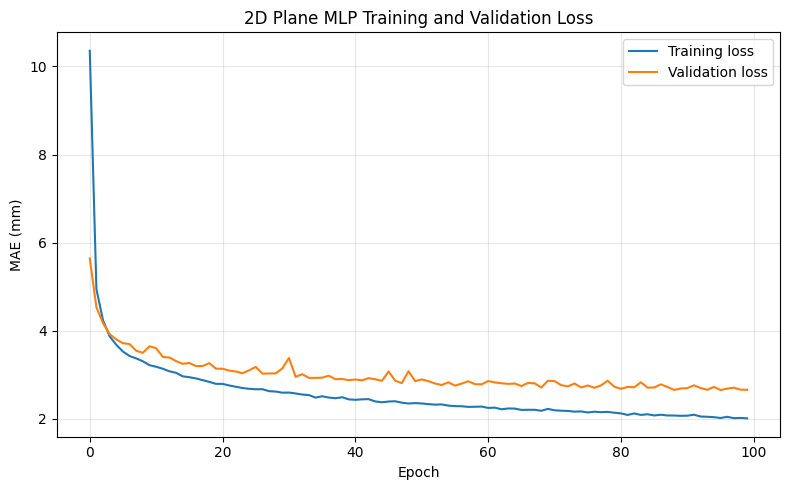

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_planeSCS.history["loss"],
    label="Training loss"
)

plt.plot(
    history_planeSCS.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (mm)")
plt.title("2D Plane MLP Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import r2_score

errors_plane_SCS = (
    xyz_pred_planeSCS - y_test_plane_SCS
)

absolute_errors_plane_SCS = np.abs(
    errors_plane_SCS
)

x_mae_plane_SCS = np.mean(
    absolute_errors_plane_SCS[:, 0]
)

y_mae_plane_SCS = np.mean(
    absolute_errors_plane_SCS[:, 1]
)

z_mae_plane_SCS = np.mean(
    absolute_errors_plane_SCS[:, 2]
)

print("X MAE:", x_mae_plane_SCS, "mm")
print("Y MAE:", y_mae_plane_SCS, "mm")
print("Z MAE:", z_mae_plane_SCS, "mm")

X MAE: 6.156206149260613 mm
Y MAE: 6.653758279098445 mm
Z MAE: 6.9346578185387235 mm


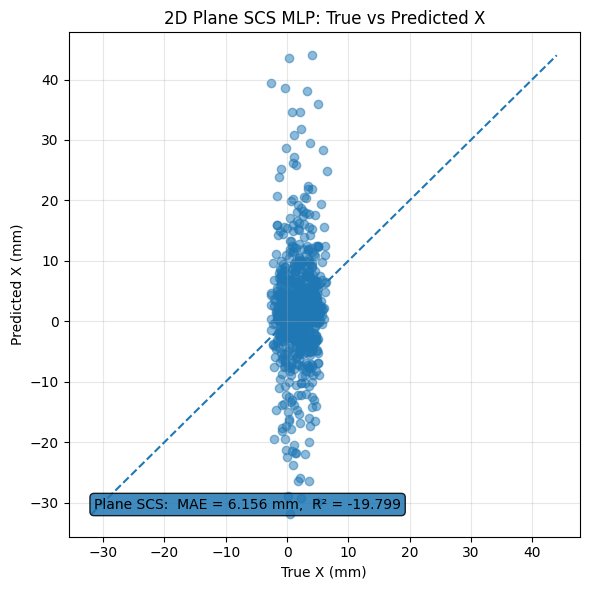

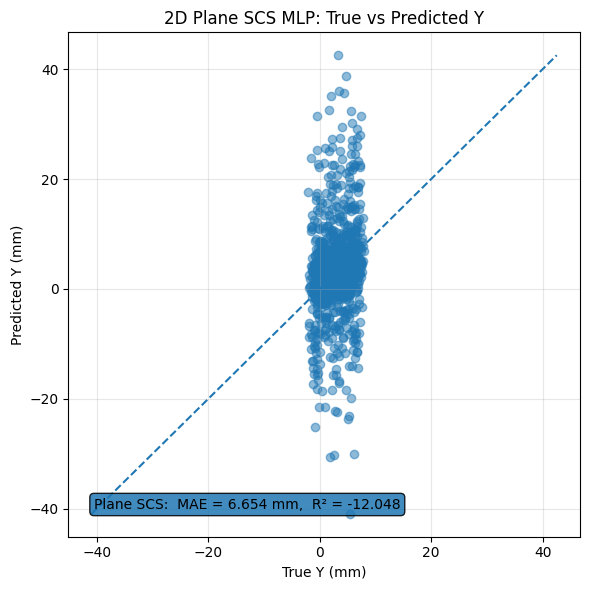

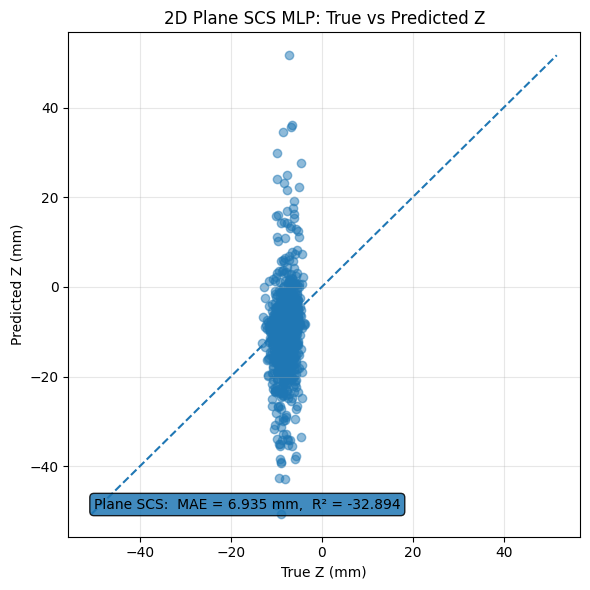

In [31]:
figures = [
    ("X", 0, x_mae_plane_SCS),
    ("Y", 1, y_mae_plane_SCS),
    ("Z", 2, z_mae_plane_SCS)
]

for coordinate, index, mae_val in figures:

    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test_plane_SCS[:, index],
        xyz_pred_planeSCS[:, index],
        alpha=0.5
    )

    minimum = min(
        y_test_plane_SCS[:, index].min(),
        xyz_pred_planeSCS[:, index].min()
    )

    maximum = max(
        y_test_plane_SCS[:, index].max(),
        xyz_pred_planeSCS[:, index].max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    r2_plane_SCS = r2_score(
        y_test_plane_SCS[:, index],
        xyz_pred_planeSCS[:, index]
    )

    metrics_text = (
        f"Plane SCS:  MAE = {mae_val:.3f} mm,  R² = {r2_plane_SCS:.3f}"
    )

    plt.text(
        0.05,
        0.05,
        metrics_text,
        transform=plt.gca().transAxes,
        verticalalignment="bottom",
        bbox=dict(
            boxstyle="round",
            alpha=0.85
        )
    )

    plt.xlabel(f"True {coordinate} (mm)")
    plt.ylabel(f"Predicted {coordinate} (mm)")
    plt.title(
        f"2D Plane SCS MLP: True vs Predicted {coordinate}"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
model_errors_plane2d = np.linalg.norm(
    xyz_pred_plane2d - y_test_plane2d,
    axis=1
)

mean_error_plane2d = np.mean(
    model_errors_plane2d
)

median_error_plane2d = np.median(
    model_errors_plane2d
)

std_error_plane2d = np.std(
    model_errors_plane2d
)

max_error_plane2d = np.max(
    model_errors_plane2d
)

print("2D PLANE MLP PERFORMANCE")

print(f"Mean 3D error   : {mean_error_plane2d:.3f} mm")
print(f"Median 3D error : {median_error_plane2d:.3f} mm")
print(f"Std 3D error    : {std_error_plane2d:.3f} mm")
print(f"Maximum error   : {max_error_plane2d:.3f} mm")

print()

print(f"X MAE           : {x_mae_plane2d:.3f} mm")
print(f"Y MAE           : {y_mae_plane2d:.3f} mm")
print(f"Z MAE           : {z_mae_plane2d:.3f} mm")

print()


print("PLANE CONSTRAINT")

plane_points = plane_test_plane2d[:, 0:3]
plane_normals = plane_test_plane2d[:, 3:6]

plane_distances_plane2d = np.abs(
    np.sum(
        (xyz_pred_plane2d - plane_points)
        * plane_normals,
        axis=1
    )
)

print(
    f"Mean plane distance   : "
    f"{np.mean(plane_distances_plane2d):.6f} mm"
)

print(
    f"Median plane distance : "
    f"{np.median(plane_distances_plane2d):.6f} mm"
)

print(
    f"Maximum plane distance: "
    f"{np.max(plane_distances_plane2d):.6f} mm"
)

2D PLANE MLP PERFORMANCE
Mean 3D error   : 0.303 mm
Median 3D error : 0.224 mm
Std 3D error    : 0.349 mm
Maximum error   : 6.516 mm

X MAE           : 0.157 mm
Y MAE           : 0.155 mm
Z MAE           : 0.142 mm

PLANE CONSTRAINT
Mean plane distance   : 0.000000 mm
Median plane distance : 0.000000 mm
Maximum plane distance: 0.000000 mm


In [ ]:
mean_position_plane2d = np.mean(
    y_train_plane2d,
    axis=0
)

print(
    "Mean annihilation position (train):",
    mean_position_plane2d
)

mean_predictions_plane2d = np.tile(
    mean_position_plane2d,
    (len(y_test_plane2d), 1)
)

mean_errors_plane2d = np.linalg.norm(
    mean_predictions_plane2d - y_test_plane2d,
    axis=1
)

baseline_mean_plane2d = np.mean(
    mean_errors_plane2d
)

baseline_median_plane2d = np.median(
    mean_errors_plane2d
)

print(
    "\nMean-position baseline — mean 3D error:",
    baseline_mean_plane2d,
    "mm"
)

print(
    "Mean-position baseline — median 3D error:",
    baseline_median_plane2d,
    "mm"
)

improvement_plane2d = (
    (baseline_mean_plane2d - mean_error_plane2d)
    / baseline_mean_plane2d
    * 100
)

print(
    f"\n2D plane MLP mean 3D error: "
    f"{mean_error_plane2d:.3f} mm"
)

print(
    f"Baseline mean 3D error: "
    f"{baseline_mean_plane2d:.3f} mm"
)

print(
    f"Improvement over baseline: "
    f"{improvement_plane2d:.1f}%"
)

Mean annihilation position (train): [ 1.82516059  3.00046503 -8.14236138]

Mean-position baseline — mean 3D error: 3.5481860379629215 mm
Mean-position baseline — median 3D error: 3.6685539241921443 mm

2D plane MLP mean 3D error: 0.303 mm
Baseline mean 3D error: 3.548 mm
Improvement over baseline: 91.5%


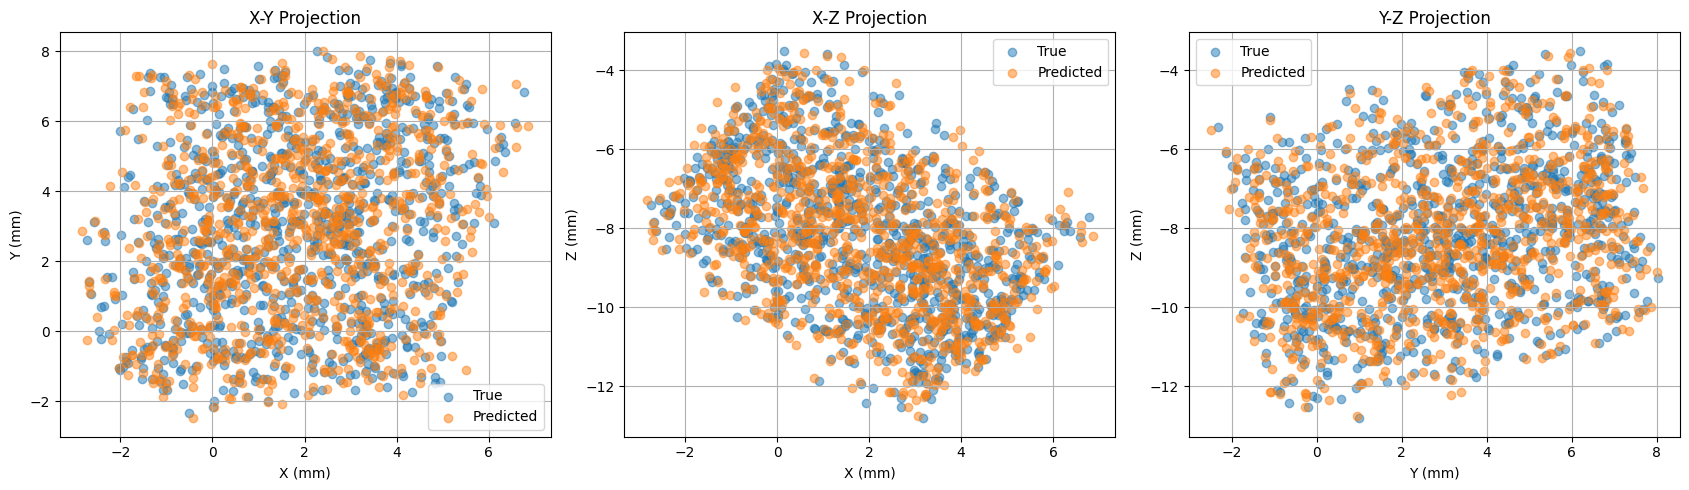

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
projections = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

for ax, (i, j, xname, yname) in zip(axes, projections):
    ax.scatter(y_test_plane2d[:, i], y_test_plane2d[:, j], alpha=0.5, label="True")
    ax.scatter(xyz_pred_plane2d[:, i], xyz_pred_plane2d[:, j], alpha=0.5, label="Predicted")
    ax.set_xlabel(f"{xname} (mm)")
    ax.set_ylabel(f"{yname} (mm)")
    ax.set_title(f"{xname}-{yname} Projection")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

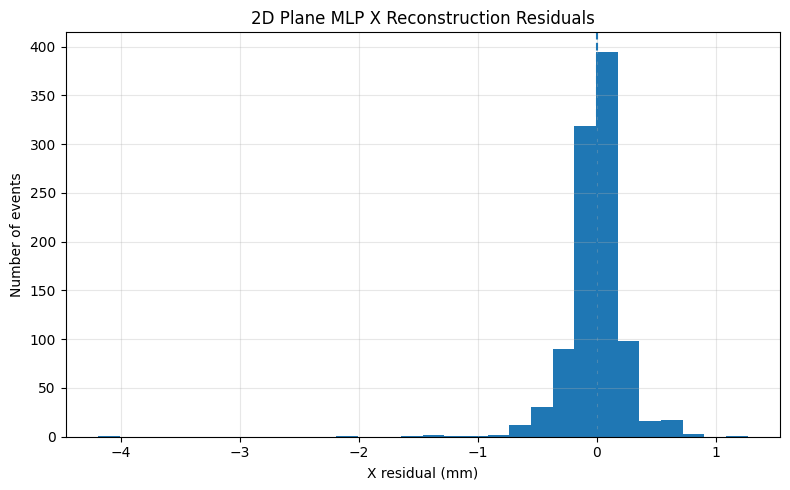

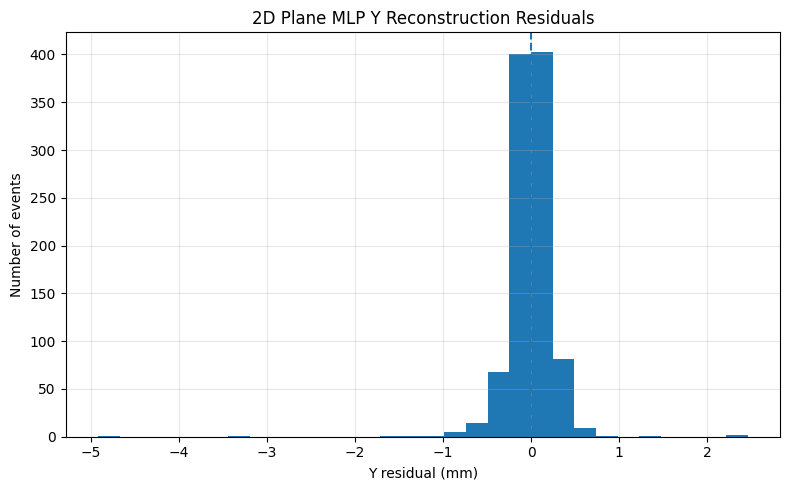

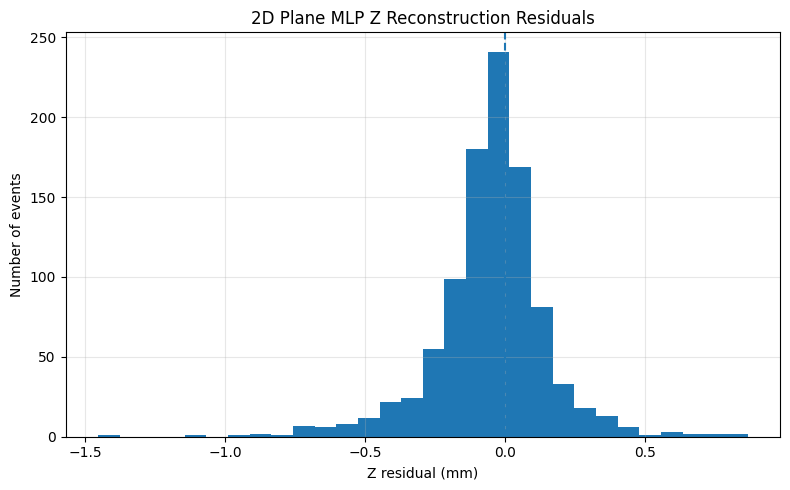

In [ ]:
for coordinate, index in [
    ("X", 0),
    ("Y", 1),
    ("Z", 2)
]:

    plt.figure(figsize=(8, 5))

    plt.hist(
        errors_plane2d[:, index],
        bins=30
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel(f"{coordinate} residual (mm)")
    plt.ylabel("Number of events")
    plt.title(
        f"2D Plane MLP {coordinate} Reconstruction Residuals"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

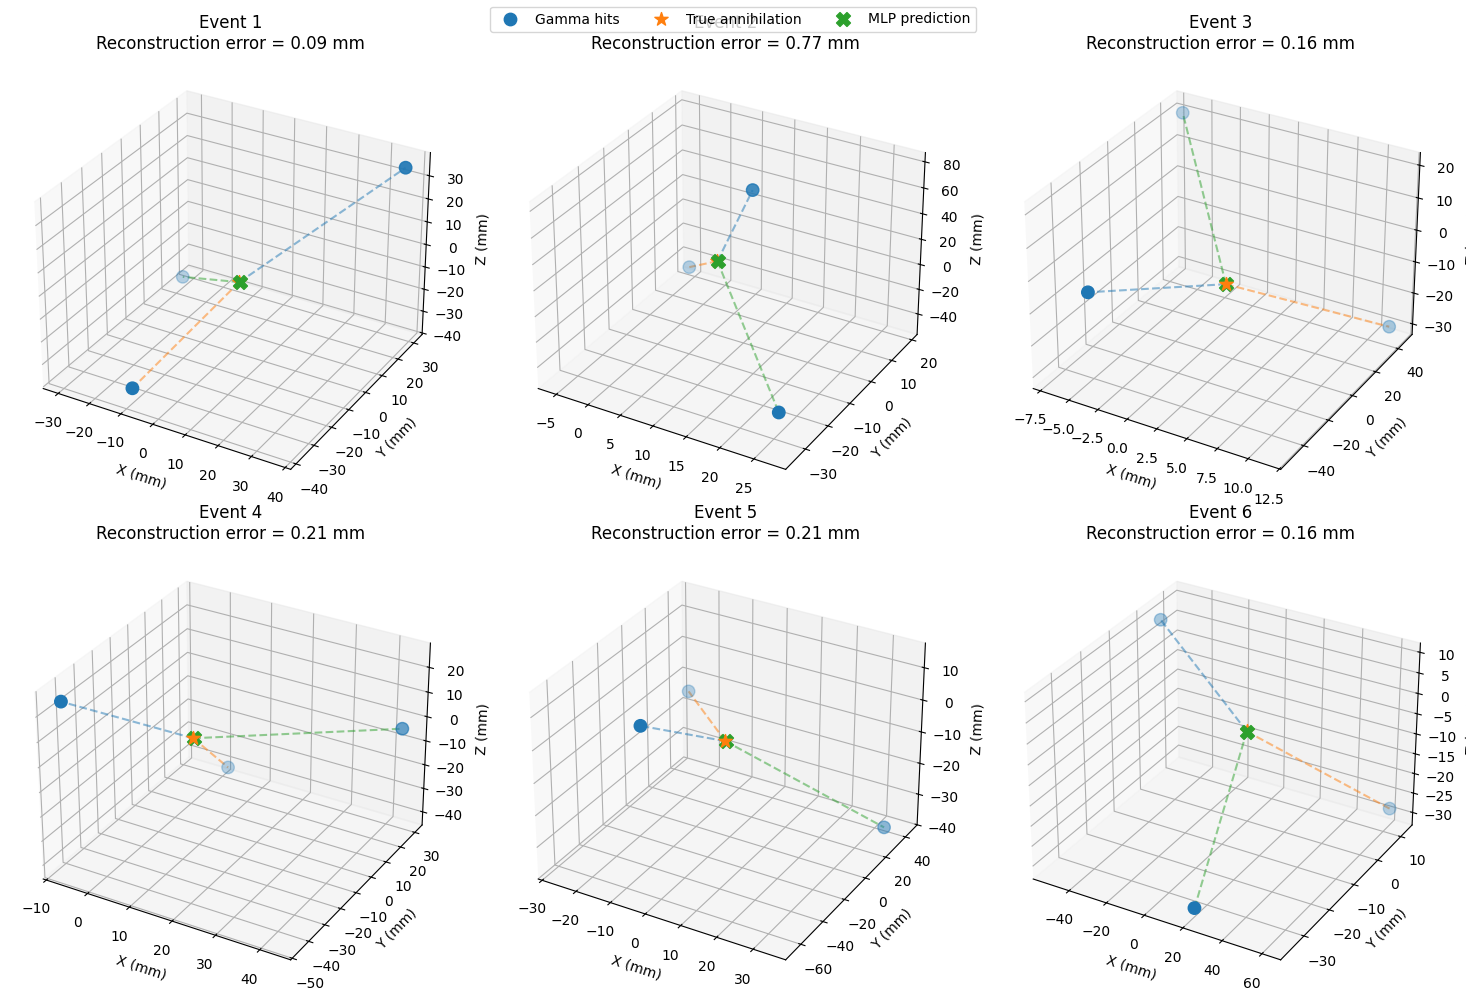

In [ ]:
n_events = min(6, len(X_test_plane2d))

fig = plt.figure(figsize=(15, 10))

for i in range(n_events):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")

    # Use X_test_plane2d for features
    hits = np.array([X_test_plane2d[i, 0:3], X_test_plane2d[i, 4:7], X_test_plane2d[i, 8:11]])
    # Use y_test_plane2d for true positions
    true_pos = y_test_plane2d[i]
    # Use xyz_pred_plane2d for predicted positions
    pred_pos = xyz_pred_plane2d[i]

    ax.scatter(hits[:, 0], hits[:, 1], hits[:, 2], s=80, marker="o", label="Gamma hits")
    ax.scatter(*true_pos, s=100, marker="*", label="True annihilation")
    ax.scatter(*pred_pos, s=100, marker="X", label="MLP prediction")

    for hit in hits:
        ax.plot([true_pos[0], hit[0]], [true_pos[1], hit[1]], [true_pos[2], hit[2]],
                linestyle="--", alpha=0.5)

    ax.plot([true_pos[0], pred_pos[0]], [true_pos[1], pred_pos[1]], [true_pos[2], pred_pos[2]],
            linestyle=":", linewidth=2)

    error = np.linalg.norm(pred_pos - true_pos)
    ax.set_title(f"Event {i+1}\nReconstruction error = {error:.2f} mm")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout()
plt.show()